# data

In [1]:
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
from pathlib import Path
import calendar

START = "2015-04-01"
END   = "2025-06-30"

In [2]:
import os
import glob
import pandas as pd

PORT_DIR = "responses_portfolios"

def _find_date_col(df: pd.DataFrame) -> str:
    for c in ["date_key", "Date", "date", "ym"]:
        if c in df.columns:
            return c
    # fallback: first unnamed index column
    if len(df.columns) > 0 and str(df.columns[0]).lower().startswith("unnamed"):
        df = df.rename(columns={df.columns[0]: "date_key"})
        return "date_key"
    raise ValueError(f"Aucune colonne de date trouvée. Colonnes: {list(df.columns)}")

def _read_and_standardize(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    date_col = _find_date_col(df)

    # Standardize to 'date_key' as datetime
    if date_col == "ym":
        # 'YYYY-MM' -> month start
        df["date_key"] = pd.to_datetime(df["ym"].astype(str) + "-01", errors="coerce")
    else:
        df["date_key"] = pd.to_datetime(df[date_col], errors="coerce")

    # drop original date cols (except date_key)
    drop_cols = [c for c in ["Date", "date", "ym"] if c in df.columns and c != "date_key"]
    df = df.drop(columns=drop_cols, errors="ignore")

    # keep only rows with date
    df = df.dropna(subset=["date_key"]).copy()
    return df

def combine_monthly_portfolios(
    pattern: str,
    out_path: str,
) -> pd.DataFrame:
    files = sorted(glob.glob(os.path.join(PORT_DIR, pattern)))
    if not files:
        raise FileNotFoundError(f"Aucun fichier trouvé avec le pattern: {PORT_DIR}/{pattern}")

    dfs = []
    for f in files:
        df = _read_and_standardize(f)
        df["source_file"] = os.path.basename(f)  # pratique pour debug
        dfs.append(df)

    out = pd.concat(dfs, ignore_index=True)

    # sort & drop duplicates by date (keep last)
    out = out.sort_values("date_key")
    out = out.drop_duplicates(subset=["date_key"], keep="last").reset_index(drop=True)

    # save combined
    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    out.to_csv(out_path, index=False)
    return out

# ---- Build combined baseline files ----
eq_combined = combine_monthly_portfolios(
    pattern="equal_weighted_portfolio*.csv",
    out_path=os.path.join(PORT_DIR, "equal_weighted_portfolio.csv"),
)

opt_combined = combine_monthly_portfolios(
    pattern="optimized_portfolio*.csv",
    out_path=os.path.join(PORT_DIR, "optimized_portfolio.csv"),
)

print("Baselines combinés :")
print(" -", os.path.join(PORT_DIR, "equal_weighted_portfolio.csv"), "(", len(eq_combined), "rows )")
print(" -", os.path.join(PORT_DIR, "optimized_portfolio.csv"), "(", len(opt_combined), "rows )")
display(eq_combined.head())
display(opt_combined.head())


Baselines combinés :
 - responses_portfolios\equal_weighted_portfolio.csv ( 125 rows )
 - responses_portfolios\optimized_portfolio.csv ( 125 rows )


,Portfolio_Return,date_key,source_file
0,0.062347,2015-02-01,equal_weighted_portfolio_2015-01-01_2015-01-31...
1,-0.009142,2015-03-01,equal_weighted_portfolio_2015-02-01_2015-02-28...
2,0.005070,2015-04-01,equal_weighted_portfolio_2015-03-01_2015-03-31...
3,0.008587,2015-05-01,equal_weighted_portfolio_2015-04-01_2015-04-30...
4,-0.019012,2015-06-01,equal_weighted_portfolio_2015-05-01_2015-05-31...


,Portfolio_Return,date_key,source_file
0,0.062347,2015-02-01,optimized_portfolio_2015-01-01_2015-01-31.csv
1,-0.009142,2015-03-01,optimized_portfolio_2015-02-01_2015-02-28.csv
2,0.005070,2015-04-01,optimized_portfolio_2015-03-01_2015-03-31.csv
3,0.008587,2015-05-01,optimized_portfolio_2015-04-01_2015-04-30.csv
4,-0.019012,2015-06-01,optimized_portfolio_2015-05-01_2015-05-31.csv


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

"""
Baselines portfolio returns (generated by baselines.py)
Expected files:
  - responses_portfolios/equal_weighted_portfolio.csv
  - responses_portfolios/optimized_portfolio.csv
"""
equal_weighted_portfolio_returns = pd.read_csv('responses_portfolios/equal_weighted_portfolio.csv')
optimized_portfolio_returns      = pd.read_csv('responses_portfolios/optimized_portfolio.csv')

equal_weighted_portfolio_returns.head()


,Portfolio_Return,date_key,source_file
0,0.062347,2015-02-01,equal_weighted_portfolio_2015-01-01_2015-01-31...
1,-0.009142,2015-03-01,equal_weighted_portfolio_2015-02-01_2015-02-28...
2,0.005070,2015-04-01,equal_weighted_portfolio_2015-03-01_2015-03-31...
3,0.008587,2015-05-01,equal_weighted_portfolio_2015-04-01_2015-04-30...
4,-0.019012,2015-06-01,equal_weighted_portfolio_2015-05-01_2015-05-31...


In [4]:
"""
GPT monthly portfolio weights (Black-Litterman output from evaluate_multiple_updated.py)
"""
import pandas as pd
import numpy as np

tau = 0.025

weights_path = f"results/gpt_black_litterman_weights_tau_{tau}.csv"
gpt_weights_df = pd.read_csv(weights_path)

# detect date column
if "Date" in gpt_weights_df.columns:
    date_col = "Date"
elif "date_key" in gpt_weights_df.columns:
    date_col = "date_key"
else:
    date_col = gpt_weights_df.columns[0]

gpt_weights_df[date_col] = pd.to_datetime(gpt_weights_df[date_col], errors="coerce")
gpt_weights_df = gpt_weights_df.dropna(subset=[date_col]).set_index(date_col).sort_index()

# transpose for plotting: rows=tickers, columns=dates
gpt_results = gpt_weights_df.T


In [5]:
"""
Gemma3 1B monthly portfolio weights (Black-Litterman output from evaluate_multiple.py)
"""
import pandas as pd

tau = 0.025

weights_path = f"results/gemma3_black_litterman_weights_tau_{tau}.csv"
gemma_weights_df = pd.read_csv(weights_path)

# detect date column
if "Date" in gemma_weights_df.columns:
    date_col = "Date"
elif "date_key" in gemma_weights_df.columns:
    date_col = "date_key"
else:
    date_col = gemma_weights_df.columns[0]

gemma_weights_df[date_col] = pd.to_datetime(gemma_weights_df[date_col], errors="coerce")
gemma_weights_df = gemma_weights_df.dropna(subset=[date_col]).set_index(date_col).sort_index()

# transpose for plotting: rows=tickers, columns=dates
gemma_results = gemma_weights_df.T


In [6]:
"""
Qwen2.5 1.5B monthly portfolio weights (Black-Litterman output)
"""
import glob
import pandas as pd
import numpy as np

tau = 0.025

# Try a couple of common naming conventions
patterns = [
    f"results/qwen_black_litterman_weights_tau_{tau}.csv",
    f"results/qwen_black_litterman_weights_tau_{tau}_*.csv",
]

candidates = []
for pat in patterns:
    candidates += sorted(glob.glob(pat))

# If both exact + wildcard matched, keep unique
candidates = sorted(set(candidates))
if not candidates:
    raise FileNotFoundError(
        "Could not find Qwen weights CSV in results/. Tried patterns:"
        + "".join(f"- {p}" for p in patterns)
        + "Generate it first (e.g., evaluate_multiple / calculate_llm_returns)."
    )

qwen_weights_path = candidates[-1]
print("Using:", qwen_weights_path)
qwen_weights_df = pd.read_csv(qwen_weights_path)

# detect date column
if "Date" in qwen_weights_df.columns:
    date_col = "Date"
elif "date_key" in qwen_weights_df.columns:
    date_col = "date_key"
else:
    date_col = qwen_weights_df.columns[0]

qwen_weights_df[date_col] = pd.to_datetime(qwen_weights_df[date_col], errors="coerce")
qwen_weights_df = qwen_weights_df.dropna(subset=[date_col]).set_index(date_col).sort_index()

# transpose for plotting: rows=tickers, columns=dates
qwen_results = qwen_weights_df.T
qwen_results.head()


Using: results/qwen_black_litterman_weights_tau_0.025.csv


Date,2015-01-01,2015-02-01,2015-03-01,2015-04-01,2015-05-01,2015-06-01,2015-07-01,2015-08-01,2015-09-01,2015-10-01,...,2024-08-01,2024-09-01,2024-10-01,2024-11-01,2024-12-01,2025-01-01,2025-02-01,2025-03-01,2025-04-01,2025-05-01
A,0.002667,3.269676e-19,3.392596e-19,2.966523e-18,1.082267e-19,0.000000e+00,0.000000e+00,5.586507e-18,1.803633e-17,0.000000e+00,...,0.000000e+00,0.0,0.0,0.0,0.0,4.224483e-17,0.000000e+00,6.088230e-18,0.000000e+00,2.515761e-17
AABA,0.001444,2.886771e-04,0.000000e+00,0.000000e+00,3.786126e-18,7.274737e-18,6.016467e-18,3.667562e-18,7.805988e-18,0.000000e+00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AAL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AAP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AAPL,0.005473,5.515163e-04,5.004713e-19,0.000000e+00,1.745103e-17,0.000000e+00,1.714871e-17,0.000000e+00,7.616102e-18,3.123668e-18,...,3.997130e-17,0.0,0.0,0.0,0.0,0.000000e+00,2.039341e-17,0.000000e+00,3.184360e-17,0.000000e+00


In [7]:
# """
# None (no-views) monthly portfolio weights (Black-Litterman output)
# """
# import glob
# import pandas as pd

# tau = 0.025

# patterns = [
#     f"results/None_black_litterman_weights_tau_{tau}.csv",
#     f"results/none_black_litterman_weights_tau_{tau}.csv",
#     f"results/None_black_litterman_weights_tau_{tau}_*.csv",
#     f"results/none_black_litterman_weights_tau_{tau}_*.csv",
# ]

# candidates = []
# for pat in patterns:
#     candidates += sorted(glob.glob(pat))

# candidates = sorted(set(candidates))
# if not candidates:
#     raise FileNotFoundError(
#         "Could not find None (no-views) weights CSV in results/. "
#         "Tried patterns:\n- " + "\n- ".join(patterns)
#     )

# none_weights_path = candidates[-1]
# print(f"Using None weights file: {none_weights_path}")

# none_weights_df = pd.read_csv(none_weights_path)

# # detect date column
# if "Date" in none_weights_df.columns:
#     date_col = "Date"
# elif "date_key" in none_weights_df.columns:
#     date_col = "date_key"
# else:
#     date_col = none_weights_df.columns[0]

# none_weights_df[date_col] = pd.to_datetime(none_weights_df[date_col], errors="coerce")
# none_weights_df = none_weights_df.dropna(subset=[date_col]).set_index(date_col).sort_index()

# # transpose for plotting: rows=tickers, columns=dates
# none_results = none_weights_df.T


In [8]:
"""
Llama3.2 monthly portfolio weights (Black-Litterman output)
"""
import glob
import pandas as pd
import numpy as np

tau = 0.025

# Try a couple of common naming conventions
patterns = [
    f"results/llama_black_litterman_weights_tau_{tau}.csv",
    f"results/llama_black_litterman_weights_tau_{tau}_*.csv",
]

candidates = []
for pat in patterns:
    candidates += sorted(glob.glob(pat))

# If both exact + wildcard matched, keep unique
candidates = sorted(set(candidates))
if not candidates:
    raise FileNotFoundError(
        "Could not find Llama weights CSV in results/. Tried patterns:"
        + "".join(f"- {p}" for p in patterns)
        + "Generate it first (e.g., evaluate_multiple / calculate_llm_returns)."
    )

llama_weights_path = candidates[-1]
print("Using:", llama_weights_path)
llama_weights_df = pd.read_csv(llama_weights_path)

# detect date column
if "Date" in llama_weights_df.columns:
    date_col = "Date"
elif "date_key" in llama_weights_df.columns:
    date_col = "date_key"
else:
    date_col = llama_weights_df.columns[0]

llama_weights_df[date_col] = pd.to_datetime(llama_weights_df[date_col], errors="coerce")
llama_weights_df = llama_weights_df.dropna(subset=[date_col]).set_index(date_col).sort_index()

# transpose for plotting: rows=tickers, columns=dates
llama_results = llama_weights_df.T
llama_results.head()


Using: results/llama_black_litterman_weights_tau_0.025.csv


Date,2015-01-01,2015-02-01,2015-03-01,2015-04-01,2015-05-01,2015-06-01,2015-07-01,2015-08-01,2015-09-01,2015-10-01,...,2024-08-01,2024-09-01,2024-10-01,2024-11-01,2024-12-01,2025-01-01,2025-02-01,2025-03-01,2025-04-01,2025-05-01
A,0.002637,0.000473,5.627210e-20,2.136915e-19,0.000000,0.000000e+00,0.000000e+00,6.896400e-19,0.000000e+00,0.000000e+00,...,0.000000e+00,1.643030e-18,6.706633e-18,6.921855e-19,1.369026e-18,3.335799e-18,1.981454e-17,2.834478e-18,3.156547e-18,7.867315e-18
AABA,0.001396,0.000741,3.263380e-03,2.880452e-03,0.000986,2.296623e-18,1.587200e-18,0.000000e+00,0.000000e+00,0.000000e+00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AAL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AAP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AAPL,0.005696,0.001989,2.470366e-04,3.641684e-05,0.000252,4.057430e-19,0.000000e+00,0.000000e+00,1.617513e-18,7.119104e-18,...,7.470132e-18,4.265381e-18,4.163146e-18,1.518861e-18,0.000000e+00,0.000000e+00,2.016938e-19,0.000000e+00,0.000000e+00,0.000000e+00


In [9]:
"""
GPT portfolio returns (generated by calculate_llm_returns.py)
"""
import glob
import pandas as pd

tau = 0.025

# Match: results/gpt_black_litterman_returns_tau_0.025_2021-01-01_2022-06-30.csv
pattern1 = f"results/gpt_black_litterman_returns_tau_{tau}_*.csv"
pattern2 = f"results/gpt_black_litterman_returns_tau_{tau}.csv"

candidates = sorted(glob.glob(pattern1))
if not candidates:
    candidates = sorted(glob.glob(pattern2))

if not candidates:
    raise FileNotFoundError(
        f"Could not find GPT returns CSV in results/. Tried patterns:\n- {pattern1}\n- {pattern2}\n"
        "Run calculate_llm_returns.py first."
    )

gpt_returns_path = candidates[-1]
print("Using:", gpt_returns_path)
gpt_returns = pd.read_csv(gpt_returns_path)
gpt_returns.head()


Using: results\gpt_black_litterman_returns_tau_0.025_2015-01-01_2025-06-30.csv


,date_key,Portfolio_Return
0,2015-02-27,0.060277
1,2015-03-31,-0.009575
2,2015-04-30,-0.001404
3,2015-05-29,0.012673
4,2015-06-30,-0.018210


In [10]:
"""
Gemma3 1B portfolio returns (generated by calculate_llm_returns.py)
"""
import glob
import pandas as pd

tau = 0.025

candidates = sorted(glob.glob(f"results/gemma3_black_litterman_returns_tau_{tau}_*.csv"))
if not candidates:
    candidates = sorted(glob.glob(f"results/gemma3_black_litterman_returns_tau_{tau}.csv"))

if not candidates:
    raise FileNotFoundError("Could not find Gemma3 returns CSV in results/. Run calculate_llm_returns.py first.")

gemma_returns_path = candidates[-1]
print("Using:", gemma_returns_path)
gemma_returns = pd.read_csv(gemma_returns_path)
gemma_returns.head()


Using: results\gemma3_black_litterman_returns_tau_0.025_2015-01-01_2025-06-30.csv


,date_key,Portfolio_Return
0,2015-02-27,0.060444
1,2015-03-31,-0.008727
2,2015-04-30,-0.001854
3,2015-05-29,0.011420
4,2015-06-30,-0.017357


In [11]:
"""
Qwen2.5 1.5B portfolio returns (generated by calculate_llm_returns.py)
"""
import glob
import pandas as pd

tau = 0.025

pattern1 = f"results/qwen_black_litterman_returns_tau_{tau}_*.csv"
pattern2 = f"results/qwen_black_litterman_returns_tau_{tau}.csv"

candidates = sorted(glob.glob(pattern1))
if not candidates:
    candidates = sorted(glob.glob(pattern2))

if not candidates:
    raise FileNotFoundError(
        f"Could not find Qwen returns CSV in results/. Tried patterns:- {pattern1}- {pattern2}"
        "Run calculate_llm_returns.py first."
    )

qwen_returns_path = candidates[-1]
print("Using:", qwen_returns_path)
qwen_returns = pd.read_csv(qwen_returns_path)
qwen_returns.head()


Using: results\qwen_black_litterman_returns_tau_0.025_2015-01-01_2025-06-30.csv


,date_key,Portfolio_Return
0,2015-02-27,0.060409
1,2015-03-31,-0.010240
2,2015-04-30,-0.009292
3,2015-05-29,0.003200
4,2015-06-30,-0.057914


In [12]:
# """
# None (no-views) portfolio returns (generated by calculate_llm_returns.py)
# """
# import glob
# import pandas as pd

# tau = 0.025

# patterns = [
#     f"results/None_black_litterman_returns_tau_{tau}_*.csv",
#     f"results/none_black_litterman_returns_tau_{tau}_*.csv",
#     f"results/None_black_litterman_returns_tau_{tau}.csv",
#     f"results/none_black_litterman_returns_tau_{tau}.csv",
# ]

# candidates = []
# for pat in patterns:
#     candidates += sorted(glob.glob(pat))

# candidates = sorted(set(candidates))
# if not candidates:
#     raise FileNotFoundError(
#         "Could not find None (no-views) returns CSV in results/. "
#         "Run calculate_llm_returns.py for model None first. Tried patterns:\n- "
#         + "\n- ".join(patterns)
#     )

# none_returns_path = candidates[-1]
# print(f"Using None returns file: {none_returns_path}")

# none_returns = pd.read_csv(none_returns_path)
# none_returns.head()


In [13]:
"""
Llama3.2 portfolio returns (generated by calculate_llm_returns.py)
"""
import glob
import pandas as pd

tau = 0.025

pattern1 = f"results/llama_black_litterman_returns_tau_{tau}_*.csv"
pattern2 = f"results/llama_black_litterman_returns_tau_{tau}.csv"

candidates = sorted(glob.glob(pattern1))
if not candidates:
    candidates = sorted(glob.glob(pattern2))

if not candidates:
    raise FileNotFoundError(
        f"Could not find Llama returns CSV in results/. Tried patterns:- {pattern1}- {pattern2}"
        "Run calculate_llm_returns.py first."
    )

llama_returns_path = candidates[-1]
print("Using:", llama_returns_path)
llama_returns = pd.read_csv(llama_returns_path)
llama_returns.head()

Using: results\llama_black_litterman_returns_tau_0.025_2015-01-01_2025-06-30.csv


,date_key,Portfolio_Return
0,2015-02-27,0.060365
1,2015-03-31,-0.008806
2,2015-04-30,-0.007850
3,2015-05-29,0.004001
4,2015-06-30,-0.026017


In [14]:
"""
S&P 500 proxy returns (monthly) from data ETF (e.g., SPY):
- Download daily adjusted prices
- Convert to monthly returns (month-end to month-end)
- Keep Jan..Jun 2025 inclusive
"""
import pandas as pd

try:
    import yfinance as yf
except ImportError:
    raise ImportError("data n'est pas installé. Fais: pip install data")

ETF = "SPY"

px = yf.download(ETF, start=START, end=END, progress=False)
if px.empty:
    raise ValueError(f"No data downloaded for {ETF}. Check internet access / ticker.")

# Prefer Adj Close if available, else Close
if "Adj Close" in px.columns:
    close = px["Adj Close"]
else:
    close = px["Close"]

# If DataFrame (edge case), take first column
if isinstance(close, pd.DataFrame):
    close = close.iloc[:, 0]

close = close.dropna()

# Month-end close and monthly returns
m_close = close.resample("ME").last()
m_ret = m_close.pct_change().dropna()

sp500_proxy = pd.DataFrame({
    "date_key": m_ret.index,
    "Portfolio_Return": m_ret.values
})

# Keep months end Jan..Jun 2023
sp500_proxy = sp500_proxy[(sp500_proxy["date_key"] >= START) & (sp500_proxy["date_key"] <= END)].copy()
sp500_proxy


C:\Users\alexi\AppData\Local\Temp\ipykernel_21944\1197347073.py:16: FutureWarning: YF.download() has changed argument auto_adjust default to True
  px = yf.download(ETF, start=START, end=END, progress=False)


,date_key,Portfolio_Return
0,2015-05-31,0.012856
1,2015-06-30,-0.020312
2,2015-07-31,0.022589
3,2015-08-31,-0.060950
4,2015-09-30,-0.025516
...,...,...
117,2025-02-28,-0.012695
118,2025-03-31,-0.055719
119,2025-04-30,-0.008670
120,2025-05-31,0.062845


# evaluate

In [15]:
import numpy as np
import pandas as pd

def _standardize_returns(df: pd.DataFrame, name: str) -> pd.Series:
    """
    Accepts df with 'Portfolio_Return' and one date column among: date_key / Date / ym.
    Returns a Series indexed by datetime at MONTH START (YYYY-MM-01).
    """
    df = df.copy()

    # Detect date column
    if "date_key" in df.columns:
        dt = pd.to_datetime(df["date_key"], errors="coerce")
    elif "Date" in df.columns:
        dt = pd.to_datetime(df["Date"], errors="coerce")
    elif "ym" in df.columns:
        dt = pd.to_datetime(df["ym"].astype(str) + "-01", errors="coerce")
    else:
        raise ValueError(f"{name}: could not find a date column in {list(df.columns)}")

    if "Portfolio_Return" not in df.columns:
        raise ValueError(f"{name}: missing 'Portfolio_Return' column")

    s = pd.Series(pd.to_numeric(df["Portfolio_Return"], errors="coerce").values, index=dt)
    s = s.dropna()

    # Normalize to month start
    s.index = s.index.to_period("M").to_timestamp()

    # Deduplicate and sort
    s = s[~s.index.duplicated(keep="last")].sort_index()
    return s

def _infer_periods_per_year(index: pd.DatetimeIndex) -> int:
    # For monthly series
    return 12

# Build return series
r_sp500 = _standardize_returns(sp500_proxy, "SP500 proxy")
r_ew    = _standardize_returns(equal_weighted_portfolio_returns, "EW")
r_mvo   = _standardize_returns(optimized_portfolio_returns, "MVO")
r_gpt   = _standardize_returns(gpt_returns, "BL-GPT")
r_gemma = _standardize_returns(gemma_returns, "BL-Gemma3_1b")
r_qwen  = _standardize_returns(qwen_returns, "BL-Qwen2.5_1.5b")
r_llama = _standardize_returns(llama_returns, "BL-Llama3.2")
# r_none  = _standardize_returns(none_returns, "BL-None (no views)")

# Align by common dates
common_idx = (r_sp500.index
    .intersection(r_ew.index)
    .intersection(r_mvo.index)
    .intersection(r_gpt.index)
    .intersection(r_gemma.index)
    .intersection(r_qwen.index)
    .intersection(r_llama.index))
    # .intersection(r_none.index))

r_sp500 = r_sp500.loc[common_idx]
r_ew    = r_ew.loc[common_idx]
r_mvo   = r_mvo.loc[common_idx]
r_gpt   = r_gpt.loc[common_idx]
r_gemma = r_gemma.loc[common_idx]
r_qwen  = r_qwen.loc[common_idx]
r_llama = r_llama.loc[common_idx]
# r_none  = r_none.loc[common_idx]


In [16]:
import numpy as np
import pandas as pd

RISK_FREE_CSV = "data/DGS1.csv"

def load_risk_free_monthly_annual(csv_path: str) -> pd.Series:
    """
    Load FRED-style CSV (DATE/observation_date, DGS1/DGS10/...) where yield is in percent,
    return a month-end series of annualized yields in decimal.
    """
    df = pd.read_csv(csv_path)

    date_col = next((c for c in df.columns if c.lower() in {"date", "observation_date"}), df.columns[0])
    val_col  = next((c for c in df.columns if c.lower() != date_col.lower()), df.columns[1])

    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
    df[val_col]  = pd.to_numeric(df[val_col], errors="coerce")
    df = df.dropna(subset=[date_col]).sort_values(date_col)

    s = df.set_index(date_col)[val_col] / 100.0  # percent -> decimal
    s = s.resample("ME").last()                  # month-end
    return s


# --- your existing prep ---
# r_none = r_none.loc[common_idx]

portfolios = {
    "SP500": r_sp500,
    "EW": r_ew,
    "MVO": r_mvo,
    "BL-gpt-4o-mini": r_gpt,
    "BL-Gemma3_1b": r_gemma,
    "BL-Qwen2.5_1.5b": r_qwen,
    "BL-Llama3.2": r_llama,
    # "BL-None (no views)": r_none,
}

ppy = _infer_periods_per_year(common_idx)

# --- NEW: dynamic risk-free aligned robustly (month period alignment) ---
rf_annual_m = load_risk_free_monthly_annual(RISK_FREE_CSV)

# Make a monthly PeriodIndex for returns
if isinstance(common_idx, pd.PeriodIndex):
    idx_month = common_idx.asfreq("M")
else:
    idx_month = pd.DatetimeIndex(common_idx).to_period("M")

# Make a monthly PeriodIndex for rf and align on periods (no MS/ME mismatch)
rf_month = rf_annual_m.copy()
rf_month.index = rf_month.index.to_period("M")
rf_annual_aligned = rf_month.reindex(idx_month).ffill().bfill()

# Put rf back on the *same index type/values* as your returns
rf_annual_aligned.index = common_idx

rf_per_period = rf_annual_aligned / float(ppy)  # per-period rf series

stats = {}
for name, returns in portfolios.items():
    returns = returns.astype(float)

    # align returns to rf index (safety)
    ret = returns.reindex(rf_per_period.index).astype(float)

    cum = (1 + ret).prod() - 1
    ann_ret = (1 + cum) ** (ppy / max(1, len(ret))) - 1
    ann_vol = ret.std(ddof=1) * np.sqrt(ppy)

    excess = ret - rf_per_period
    denom = ret.std(ddof=1)
    sharpe = (excess.mean() / denom) * np.sqrt(ppy) if denom > 0 else np.nan

    wealth = (1 + ret).cumprod()
    peak = wealth.cummax()
    dd = wealth / peak - 1
    mdd = dd.min()

    stats[name] = {
        "Cum. Return": round(float(cum), 4),
        "Ann. Return": round(float(ann_ret), 4),
        "Ann. Vol": round(float(ann_vol), 4),
        "Sharpe": round(float(sharpe), 4),
        "Max Drawdown": round(float(mdd), 4),
    }

stats_df = pd.DataFrame(stats).T
print(f"Periods/year inferred: {ppy}")
stats_df


Periods/year inferred: 12


,Cum. Return,Ann. Return,Ann. Vol,Sharpe,Max Drawdown
SP500,2.5163,0.1317,0.1537,0.7468,-0.2393
EW,2.0565,0.1162,0.1687,0.6121,-0.2611
MVO,2.3511,0.1263,0.1963,0.5968,-0.2608
BL-gpt-4o-mini,0.9662,0.0688,0.1519,0.3744,-0.2080
BL-Gemma3_1b,1.2478,0.0829,0.1482,0.4689,-0.1606
BL-Qwen2.5_1.5b,1.2927,0.0850,0.1855,0.4199,-0.3209
BL-Llama3.2,2.1572,0.1197,0.1689,0.6305,-0.1947


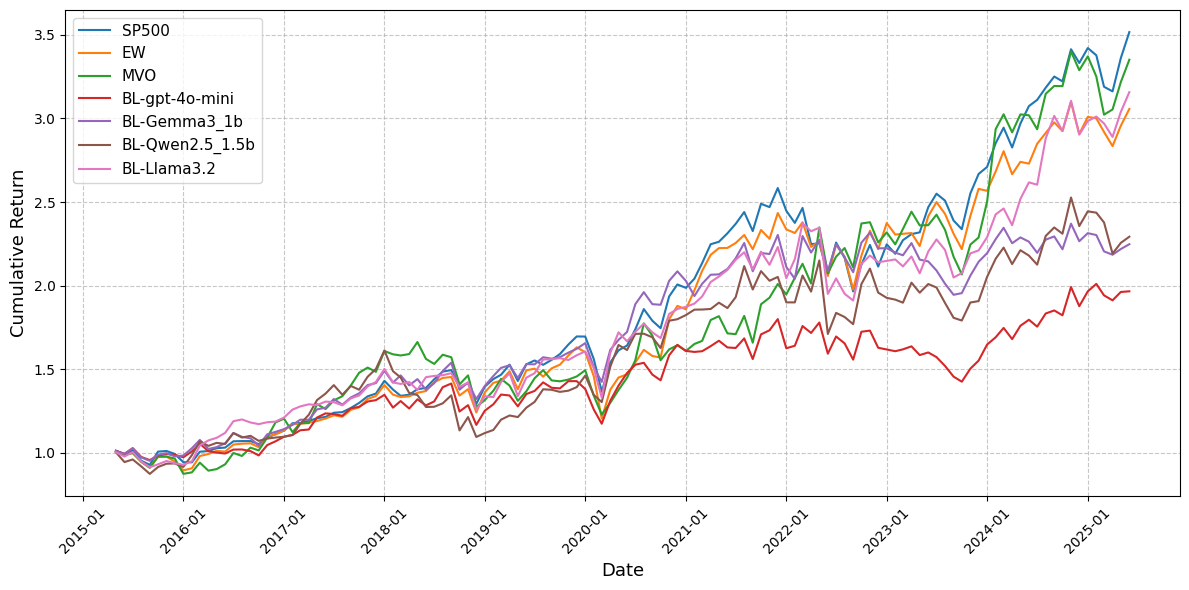

In [17]:
import matplotlib.pyplot as plt
import matplotlib

plt.figure(figsize=(12, 6))

for name, returns in portfolios.items():
    cum = (1 + returns).cumprod()
    plt.plot(cum.index, cum.values, label=name)

plt.grid(True, linestyle="--", alpha=0.7)
plt.xlabel("Date", fontsize=13)
plt.ylabel("Cumulative Return", fontsize=13)
plt.legend(loc="upper left", fontsize=11)

plt.gca().xaxis.set_major_locator(matplotlib.dates.YearLocator())
# plt.gca().xaxis.set_major_locator(matplotlib.dates.MonthLocator(interval=1))
plt.gca().xaxis.set_major_formatter(matplotlib.dates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()
